# Exploratory Data Analysis

Now that the data is cleaned and saved, I want to actually understand what's in it before jumping into modeling. EDA helps me spot patterns, check if the data makes sense, and figure out which features might actually be useful for prediction.

I'm keeping this focused — just the plots that tell a meaningful story about the data.

In [ ]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = '/content/drive/MyDrive/PTSD_Project'
processed = base + '/data/processed'
results = base + '/results'

print("done")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
done


In [ ]:
#Load data
df = pd.read_csv(processed + '/merged_clean.csv')

print("shape:", df.shape)
print("\nfirst few rows:")
df.head()

shape: (5065, 24)

first few rows:


,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,...,INDFMPIR,DMDMARTL,ALQ111,ALQ121,ALQ130,SLD012,SLQ050,SLQ120,PHQ_total,label
0,93705.0,0,0,0,0,0,0,0,0,0,...,0.82,3.0,1.0,7.0,1.0,8.0,2.0,0.0,0,0
1,93706.0,0,0,0,0,0,0,0,0,0,...,2.13,1.0,2.0,0.0,0.0,10.5,2.0,1.0,0,0
2,93708.0,0,0,0,0,0,0,0,0,0,...,1.63,1.0,2.0,0.0,0.0,8.0,2.0,2.0,0,0
3,93711.0,1,0,1,0,0,0,0,0,0,...,5.00,1.0,1.0,5.0,1.0,7.0,1.0,3.0,2,0
4,93712.0,0,0,1,0,0,0,0,0,0,...,0.76,1.0,1.0,0.0,0.0,7.5,2.0,2.0,1,0


## Label distribution and PHQ score spread

First thing I want to check is how balanced my target label is, and what the overall PHQ score distribution looks like. I'm expecting an imbalanced dataset since most people in a general population survey won't have severe depression symptoms.

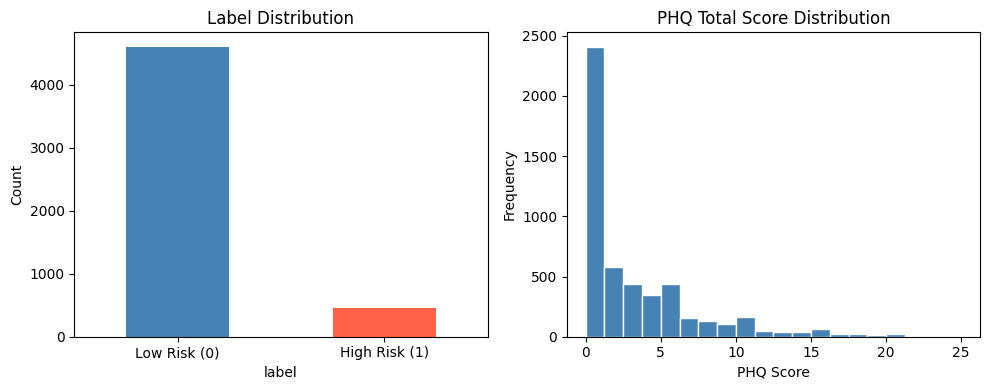

saved


In [ ]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar chart
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Label Distribution')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)
axes[0].set_ylabel('Count')

# PHQ total score distribution
df['PHQ_total'].plot(kind='hist', bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('PHQ Total Score Distribution')
axes[1].set_xlabel('PHQ Score')

plt.tight_layout()
plt.savefig(results + '/label_distribution.png', dpi=150)
plt.show()
print("saved")

The label distribution confirms what I expected — about 91.7% of patients are low risk and only 8.3% are high risk. This is a pretty imbalanced dataset.

The PHQ score histogram is heavily right skewed — most people score 0-2 meaning they have almost no symptoms. Very few people reach the 10+ threshold.

This imbalance means I can't use accuracy as my main metric. A model that just predicts "low risk" for everyone would get 91.7% accuracy but would be completely useless. I'll use F1 score and ROC-AUC instead, and use class_weight='balanced' in all models.

## Age and gender distribution by label

Checking if certain age groups or genders are more likely to be high risk.

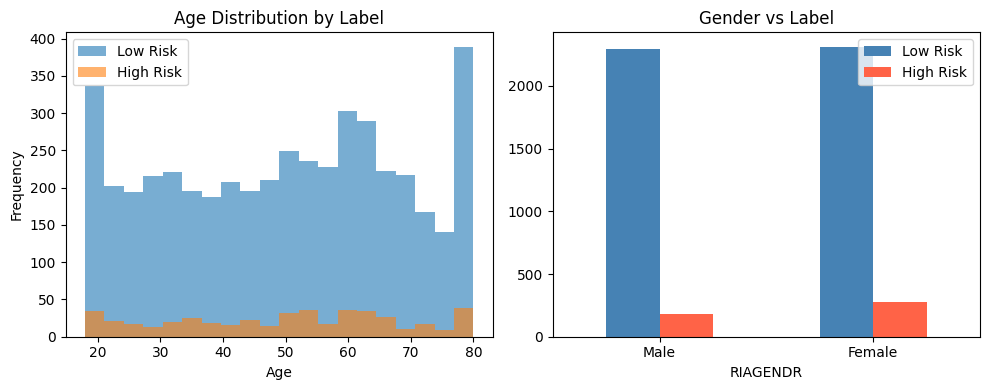

saved


In [ ]:
#Age and gender by label
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# age distribution by label
df.groupby('label')['RIDAGEYR'].plot(kind='hist', bins=20, alpha=0.6,
                                     ax=axes[0], legend=True)
axes[0].set_title('Age Distribution by Label')
axes[0].set_xlabel('Age')
axes[0].legend(['Low Risk', 'High Risk'])

# gender distribution by label
gender_counts = df.groupby(['RIAGENDR', 'label']).size().unstack()
gender_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Gender vs Label')
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
axes[1].legend(['Low Risk', 'High Risk'])

plt.tight_layout()
plt.savefig(results + '/age_gender.png', dpi=150)
plt.show()
print("saved")

Age doesn't seem to matter much — high risk patients are spread fairly evenly across all age groups. This tells me age alone probably won't be a strong predictor.

Gender is more interesting. Females have roughly double the high risk cases compared to males, even though both groups have similar total counts. This aligns with real clinical research — women are diagnosed with depression at higher rates. Worth mentioning in the report.

## Sleep hours and income by label

Checking whether sleep and income show any separation between high and low risk groups.

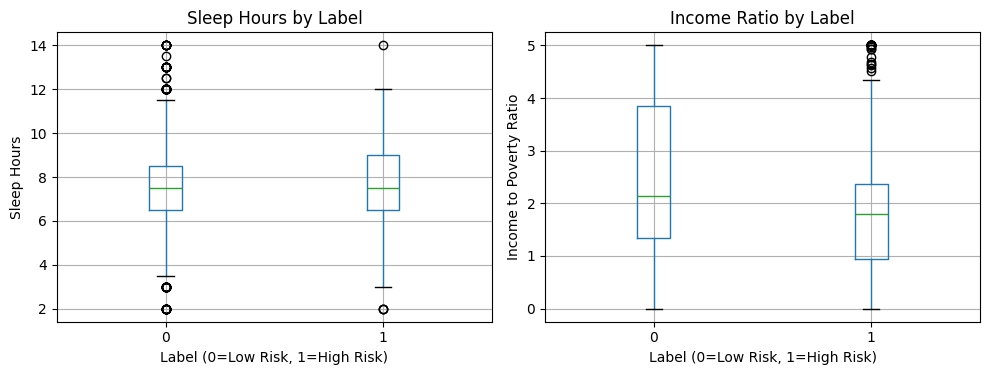

saved


In [ ]:
# Sleep and income by label
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# sleep hours by label
df.boxplot(column='SLD012', by='label', ax=axes[0])
axes[0].set_title('Sleep Hours by Label')
axes[0].set_xlabel('Label (0=Low Risk, 1=High Risk)')
axes[0].set_ylabel('Sleep Hours')
plt.suptitle('')

# income by label
df.boxplot(column='INDFMPIR', by='label', ax=axes[1])
axes[1].set_title('Income Ratio by Label')
axes[1].set_xlabel('Label (0=Low Risk, 1=High Risk)')
axes[1].set_ylabel('Income to Poverty Ratio')
plt.suptitle('')

plt.tight_layout()
plt.savefig(results + '/sleep_income.png', dpi=150)
plt.show()
print("saved")

Both plots show a lot of overlap between the two groups. The median sleep hours are similar for both labels, and income ratios aren't dramatically different either.

This confirms something important — individual features on their own won't separate the groups well. The models need to combine multiple features together to find patterns. It also hints at why the LLM might struggle — if you describe a patient with average sleep and average income, the LLM won't have strong signals to work with.

## Correlation heatmap

Looking at how features relate to each other and to the label. This helps spot multicollinearity and understand which features have the strongest relationship with risk.

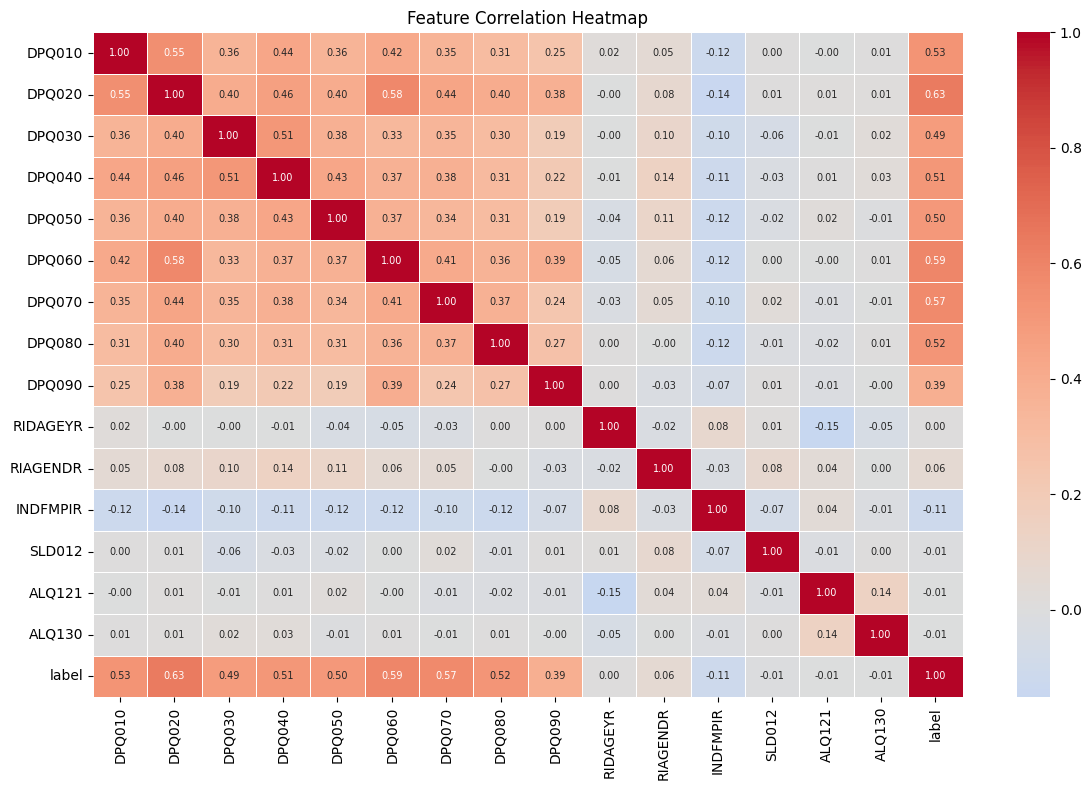

saved


In [ ]:
#correlation heatmap
plt.figure(figsize=(12, 8))

cols_for_corr = ['DPQ010','DPQ020','DPQ030','DPQ040','DPQ050',
                 'DPQ060','DPQ070','DPQ080','DPQ090',
                 'RIDAGEYR', 'RIAGENDR', 'INDFMPIR',
                 'SLD012', 'ALQ121', 'ALQ130', 'label']

corr = df[cols_for_corr].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(results + '/correlation_heatmap.png', dpi=150)
plt.show()
print("saved")

A few things stand out here:

The PHQ questions (DPQ010-DPQ090) are all moderately correlated with each other (0.3-0.6), which makes sense — depressed people tend to score high on multiple questions, not just one.

The PHQ questions also have the strongest correlation with the label (0.39-0.63). This is expected since we built the label from these questions. DPQ020 (feeling down or hopeless) has the highest correlation at 0.63.

Age, sleep, and alcohol features have near-zero correlation with the label individually. This doesn't mean they're useless — they might contribute in combination with other features, which is exactly what ML models are good at finding.

<Figure size 1000x500 with 0 Axes>

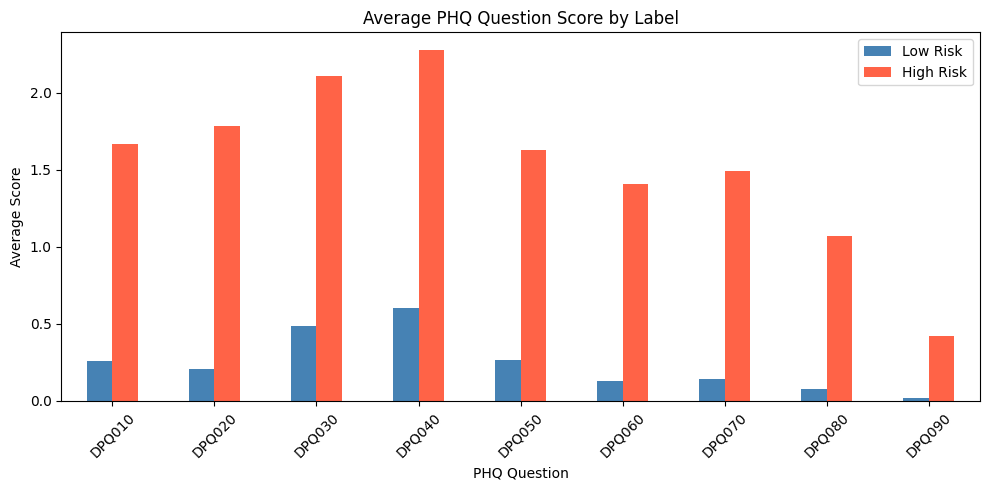

saved


In [ ]:
#PHQ question averages by label
phq_cols = ['DPQ010','DPQ020','DPQ030','DPQ040','DPQ050',
            'DPQ060','DPQ070','DPQ080','DPQ090']

phq_means = df.groupby('label')[phq_cols].mean().T

plt.figure(figsize=(10, 5))
phq_means.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'tomato'])
plt.title('Average PHQ Question Score by Label')
plt.xlabel('PHQ Question')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(['Low Risk', 'High Risk'])
plt.tight_layout()
plt.savefig(results + '/phq_by_label.png', dpi=150)
plt.show()
print("saved")

This plot makes it very clear — high risk patients score much higher on every single PHQ question compared to low risk patients. The biggest gaps are in DPQ040 (feeling down or hopeless) and DPQ030 (trouble falling asleep or sleeping too much).

DPQ090 (difficulty at work due to symptoms) is interesting — both groups score very low here. Low risk patients score low because they have no symptoms. Even high risk patients score relatively low, which might be because people underreport functional impairment.

This plot will go directly into my report as a figure showing feature separation by label.

## EDA Summary

Key findings from the data exploration:

- Dataset is imbalanced: 91.7% low risk, 8.3% high risk — will use F1 and AUC as primary metrics
- PHQ questions are the strongest predictors, all other features have weak individual correlations with the label
- Gender shows a meaningful difference — females have roughly 2x the high risk rate of males
- Age, sleep, and income don't separate the groups well on their own
- Single features are not enough to predict risk — models need to learn combinations

Next step: preprocessing — scaling, encoding, train/test split, and saving ready-to-train data.